# 02 — Exploratory Data Analysis (EDA)

Tujuan:
1. Memahami distribusi setiap variabel (univariate analysis).
2. Mengidentifikasi hubungan antar variabel dengan target `churn` (bivariate analysis).
3. Analisis korelasi antar fitur numerik.
4. Merumuskan insight bisnis awal yang akan memandu feature engineering & modeling.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import CLEAN_DATA_PATH

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (7000, 19)


,customer_id,gender,usia,kota,tenure_bulan,paket,jenis_jaringan,kuota_gb,biaya_bulanan,punya_streaming_bundle,punya_ewallet_linked,metode_bayar,jumlah_komplain_6bln,skor_kepuasan_csat,pernah_upgrade_paket,total_pemakaian_data_gb,frekuensi_login_app,churn,is_unlimited
0,CUST-00000,Male,60,Yogyakarta,19,Prabayar,5G,25,146.01,Yes,Yes,Transfer Bank,2,5,No,14.74,11,0,0
1,CUST-00001,Female,37,Lainnya,41,Hybrid,5G,50,90.54,Yes,Yes,E-Wallet,2,3,Yes,14.25,6,0,0
2,CUST-00002,Female,63,Semarang,69,Prabayar,Fiber,5,133.45,No,No,E-Wallet,0,4,No,4.63,7,0,0
3,CUST-00003,Male,44,Medan,51,Pascabayar,Fiber,999,224.06,No,No,Auto-debit,1,3,No,31.71,10,0,1
4,CUST-00004,Male,36,Lainnya,22,Prabayar,4G,50,67.05,Yes,No,E-Wallet,1,4,Yes,11.88,9,0,0


## 1. Distribusi Target (`churn`)

Memahami proporsi churn vs non-churn — krusial untuk menentukan strategi
modeling (imbalanced classification) dan interpretasi metrik nantinya.


/tmp/ipykernel_621/201071491.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'])


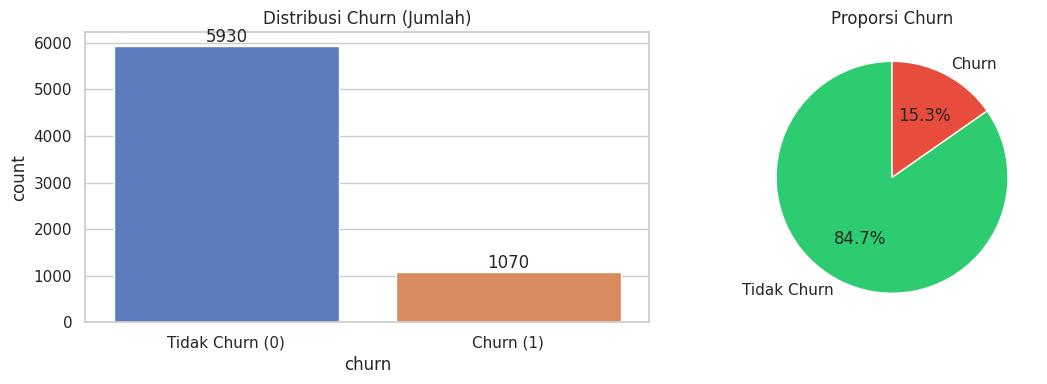

Churn rate: 15.29%
-> Dataset imbalanced (~15% churn). Akurasi saja TIDAK CUKUP sebagai metrik.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(x='churn', data=df, ax=axes[0], hue='churn', legend=False)
axes[0].set_title('Distribusi Churn (Jumlah)')
axes[0].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')

# Pie chart
churn_counts = df['churn'].value_counts()
axes[1].pie(churn_counts, labels=['Tidak Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporsi Churn')

plt.tight_layout()
plt.show()

print(f"Churn rate: {df['churn'].mean()*100:.2f}%")
print("-> Dataset imbalanced (~15% churn). Akurasi saja TIDAK CUKUP sebagai metrik.")


## 2. Univariate Analysis — Variabel Numerik Kunci

Melihat distribusi `tenure_bulan`, `biaya_bulanan`, `jumlah_komplain_6bln`,
`skor_kepuasan_csat`, dan `total_pemakaian_data_gb`.


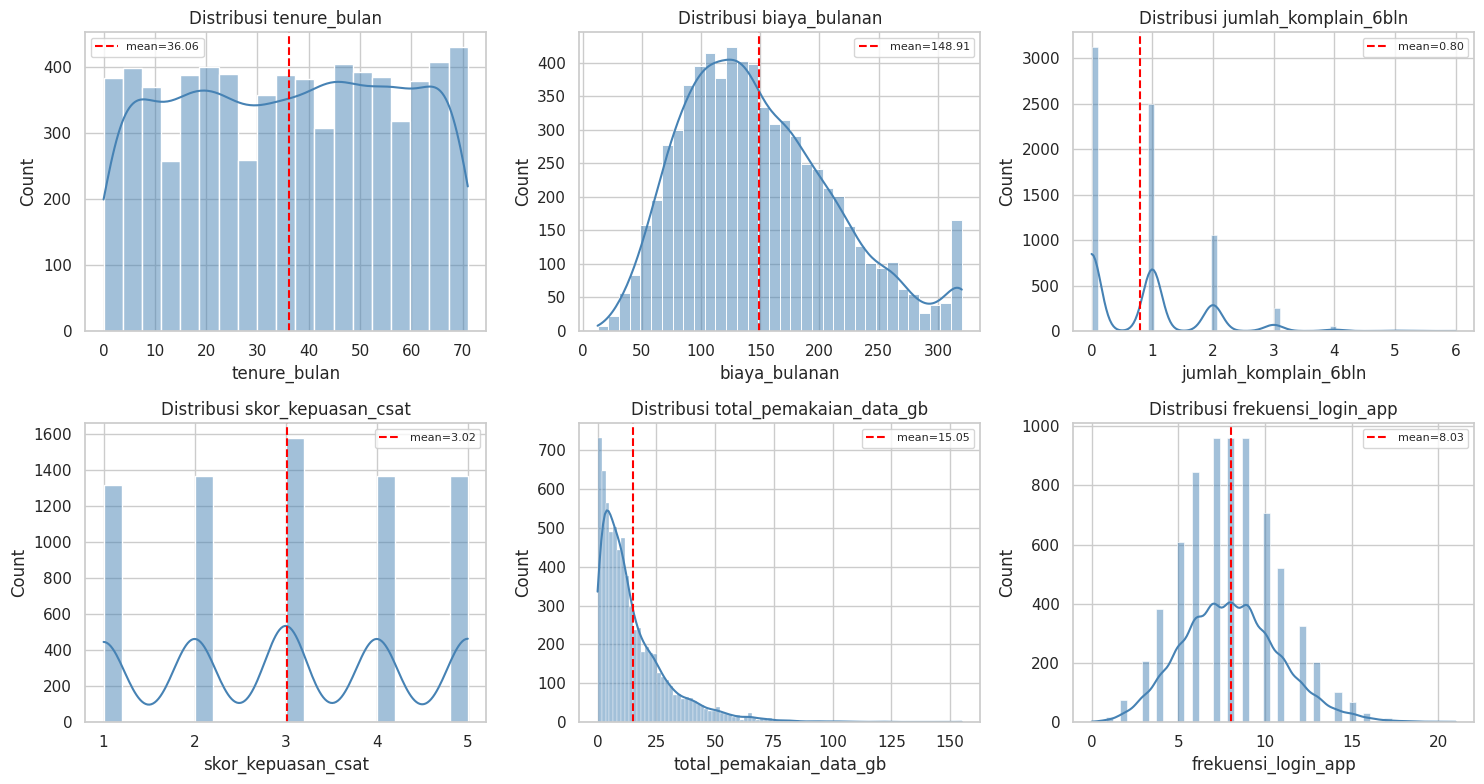

In [3]:
numeric_features = ['tenure_bulan', 'biaya_bulanan', 'jumlah_komplain_6bln',
                     'skor_kepuasan_csat', 'total_pemakaian_data_gb', 'frekuensi_login_app']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3. Bivariate Analysis — Churn vs Variabel Numerik

Membandingkan distribusi setiap variabel numerik antara pelanggan yang
churn vs tidak churn menggunakan boxplot.


/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Tidak Churn', 'Churn'])
/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Tidak Churn', 'Churn'])
/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Tidak Churn', 'Churn'])
/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Tidak Churn', 'Churn'])
/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

/tmp/ipykernel_621/2931481711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Tidak Churn', 'Churn'])


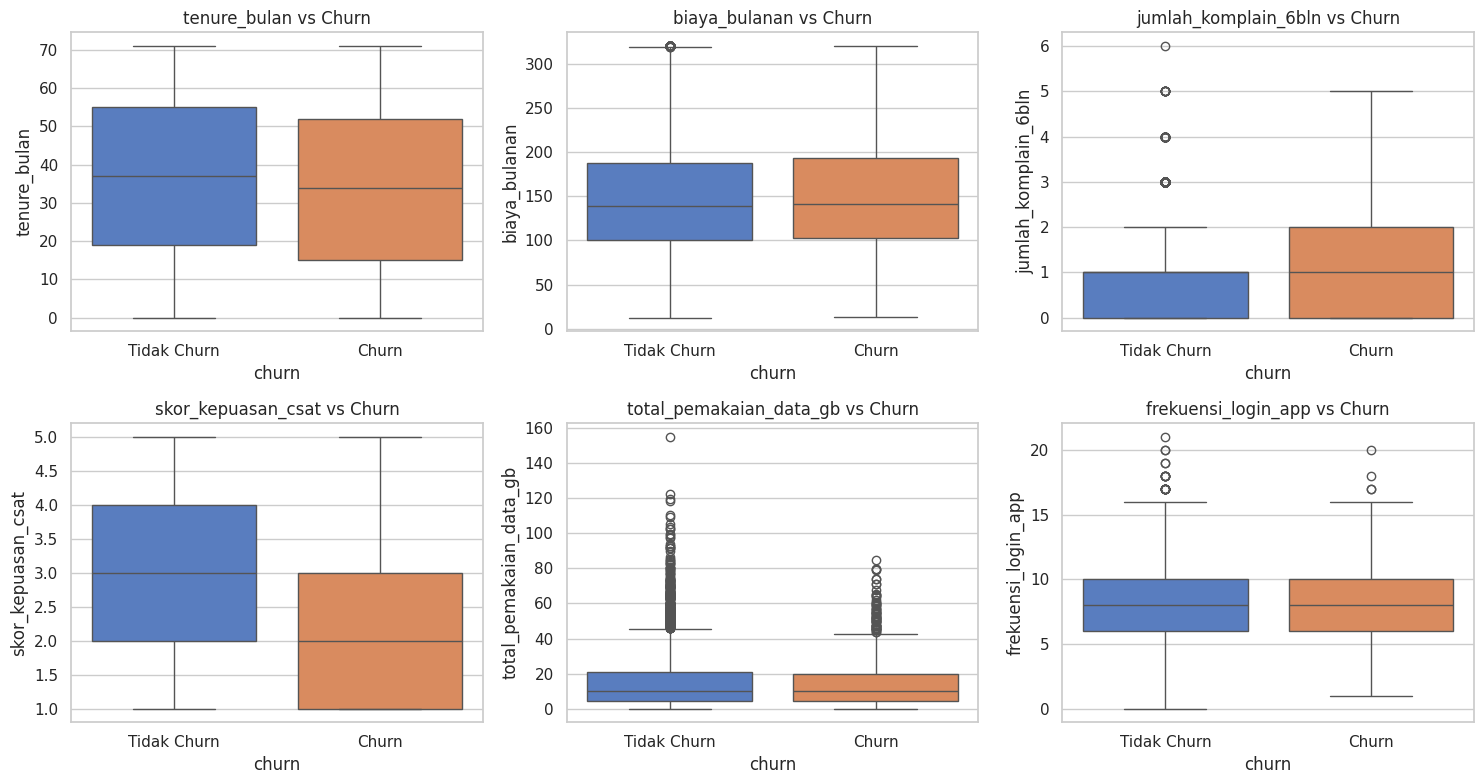

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='churn', y=col, data=df, ax=axes[i], hue='churn', legend=False)
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xticklabels(['Tidak Churn', 'Churn'])

plt.tight_layout()
plt.show()


### Insight #1: Tenure & Churn

Pelanggan yang churn cenderung memiliki **tenure yang lebih rendah**
(pelanggan baru lebih rawan churn — sering disebut "early churn").


In [5]:
tenure_summary = df.groupby('churn')['tenure_bulan'].agg(['mean', 'median', 'std']).round(2)
tenure_summary.index = ['Tidak Churn', 'Churn']
print(tenure_summary)

# Analisis tenure_group vs churn
df['tenure_group_temp'] = pd.cut(df['tenure_bulan'], bins=[0,6,12,24,48,72],
                                   labels=['0-6','6-12','12-24','24-48','48-72'],
                                   include_lowest=True)
churn_by_tenure = df.groupby('tenure_group_temp')['churn'].agg(['mean', 'count'])
churn_by_tenure.columns = ['churn_rate', 'jumlah_pelanggan']
churn_by_tenure['churn_rate'] = (churn_by_tenure['churn_rate'] * 100).round(2)
print("\nChurn rate per kelompok tenure:")
print(churn_by_tenure)

df = df.drop(columns=['tenure_group_temp'])


              mean  median    std
Tidak Churn  36.48    37.0  20.77
Churn        33.72    34.0  21.61

Churn rate per kelompok tenure:
                   churn_rate  jumlah_pelanggan
tenure_group_temp                              
0-6                     25.44               676
6-12                    12.01               558
12-24                   14.58              1159
24-48                   14.74              2293
48-72                   14.00              2314


## 4. Bivariate Analysis — Churn vs Variabel Kategorikal

Visualisasi churn rate per kategori untuk variabel-variabel kunci:
`paket`, `jenis_jaringan`, `punya_streaming_bundle`, `punya_ewallet_linked`,
`pernah_upgrade_paket`, dan `kota`.


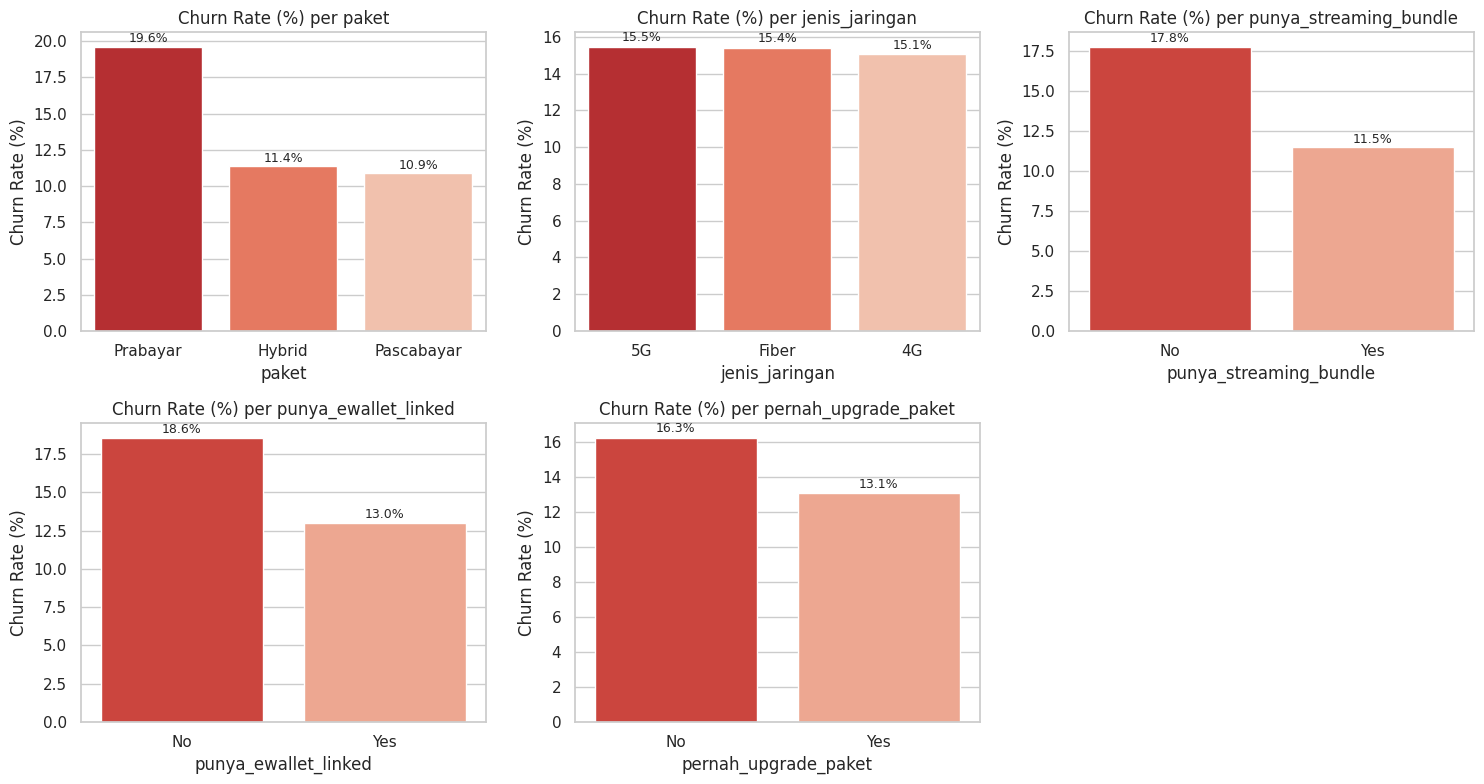

In [6]:
cat_features = ['paket', 'jenis_jaringan', 'punya_streaming_bundle',
                 'punya_ewallet_linked', 'pernah_upgrade_paket']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i], hue=churn_rate.index,
                legend=False, palette='Reds_r')
    axes[i].set_title(f'Churn Rate (%) per {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

axes[5].axis('off')  # kosongkan subplot ke-6
plt.tight_layout()
plt.show()


### Insight #2: Paket & Bundle

- Paket Prabayar memiliki churn rate lebih tinggi dibanding Pascabayar/Hybrid
  — pelanggan prabayar lebih mudah berpindah karena tidak ada kontrak/komitmen.
- Pelanggan dengan streaming bundle dan e-wallet linked memiliki churn
  rate lebih rendah — fitur-fitur ini menciptakan "stickiness" (sulit pindah
  karena terintegrasi dengan ekosistem digital pelanggan).


Churn rate per kota (urutan tertinggi):
kota
Yogyakarta    19.93
Makassar      16.45
Surabaya      16.12
Bandung       16.12
Semarang      14.87
Lainnya       14.62
Jakarta       14.18
Medan         12.65
Name: churn, dtype: float64


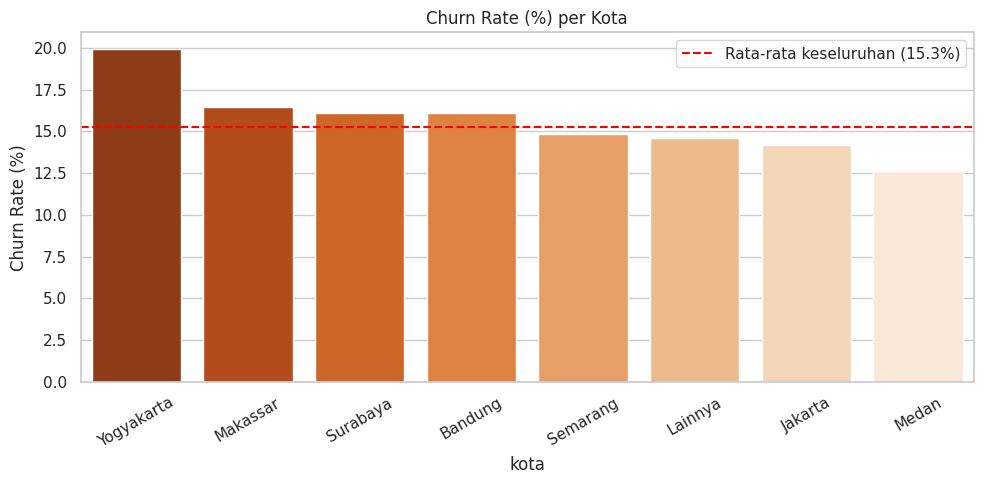

In [7]:
print("Churn rate per kota (urutan tertinggi):")
churn_by_kota = (df.groupby('kota')['churn'].mean() * 100).sort_values(ascending=False).round(2)
print(churn_by_kota)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=churn_by_kota.index, y=churn_by_kota.values, ax=ax,
            hue=churn_by_kota.index, legend=False, palette='Oranges_r')
ax.set_title('Churn Rate (%) per Kota')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(df['churn'].mean()*100, color='red', linestyle='--', label=f'Rata-rata keseluruhan ({df["churn"].mean()*100:.1f}%)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Variabel Paling Kuat: Komplain & Kepuasan (CSAT)

Berdasarkan logika generasi data, dua variabel ini diharapkan menjadi
predictor paling kuat. Mari kita validasi secara visual.


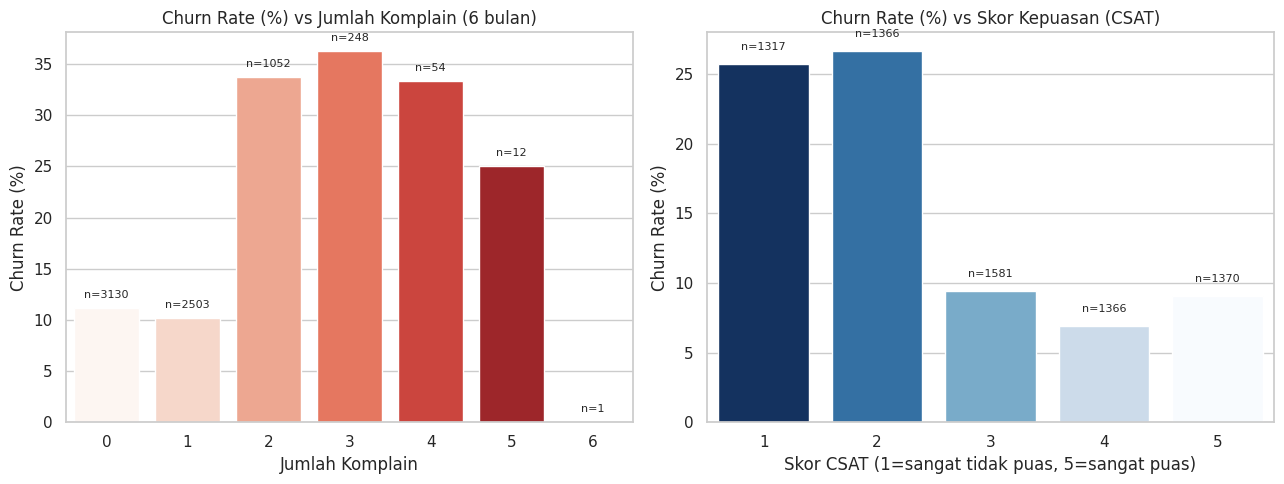

-> Pola monotonik jelas: semakin banyak komplain & semakin rendah CSAT,
   semakin tinggi churn rate. Kedua variabel ini KANDIDAT FITUR TERPENTING.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Komplain vs churn
complain_churn = df.groupby('jumlah_komplain_6bln')['churn'].agg(['mean', 'count'])
complain_churn['mean'] = complain_churn['mean'] * 100
sns.barplot(x=complain_churn.index, y=complain_churn['mean'], ax=axes[0],
            hue=complain_churn.index, legend=False, palette='Reds')
axes[0].set_title('Churn Rate (%) vs Jumlah Komplain (6 bulan)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Jumlah Komplain')
for i, (idx, row) in enumerate(complain_churn.iterrows()):
    axes[0].text(i, row['mean'] + 1, f"n={int(row['count'])}", ha='center', fontsize=8)

# CSAT vs churn
csat_churn = df.groupby('skor_kepuasan_csat')['churn'].agg(['mean', 'count'])
csat_churn['mean'] = csat_churn['mean'] * 100
sns.barplot(x=csat_churn.index, y=csat_churn['mean'], ax=axes[1],
            hue=csat_churn.index, legend=False, palette='Blues_r')
axes[1].set_title('Churn Rate (%) vs Skor Kepuasan (CSAT)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Skor CSAT (1=sangat tidak puas, 5=sangat puas)')
for i, (idx, row) in enumerate(csat_churn.iterrows()):
    axes[1].text(i, row['mean'] + 1, f"n={int(row['count'])}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("-> Pola monotonik jelas: semakin banyak komplain & semakin rendah CSAT,")
print("   semakin tinggi churn rate. Kedua variabel ini KANDIDAT FITUR TERPENTING.")


## 6. Analisis Korelasi (Variabel Numerik)

Heatmap korelasi Pearson untuk melihat hubungan linear antar variabel
numerik, termasuk korelasi dengan target `churn`.


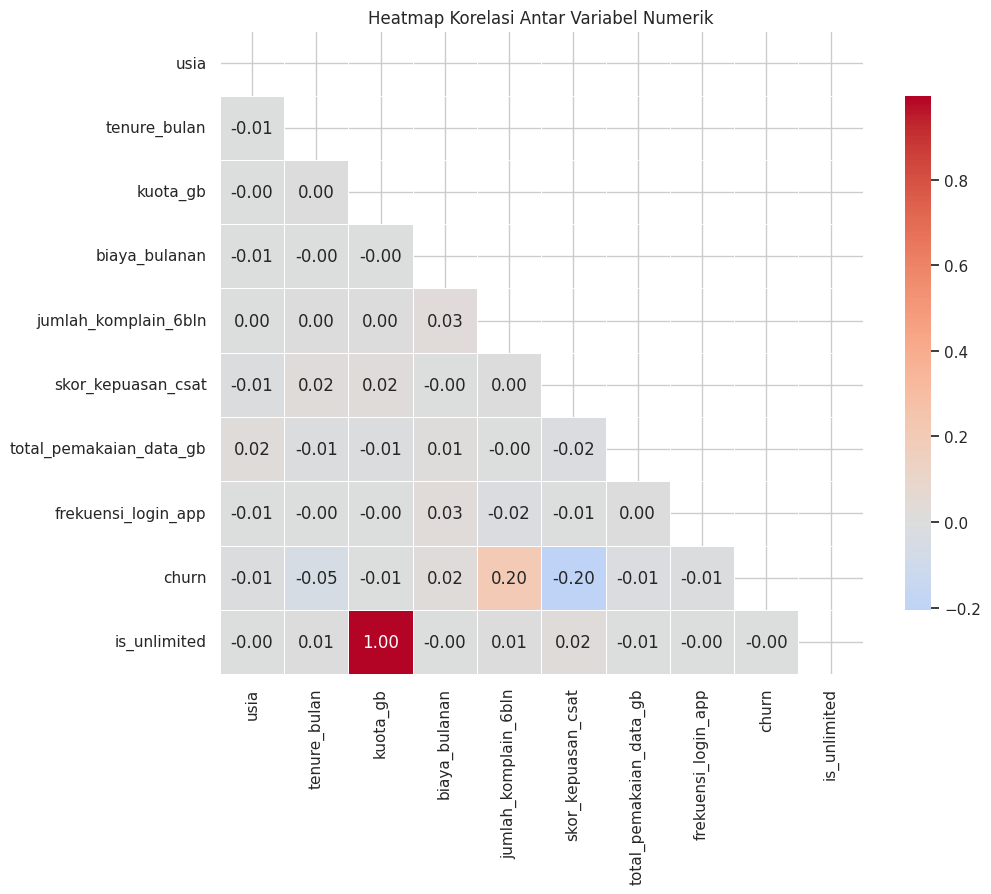

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Variabel Numerik')
plt.tight_layout()
plt.show()


In [10]:
# Korelasi spesifik dengan churn, diurutkan
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
print("Korelasi setiap variabel numerik dengan 'churn' (diurutkan |korelasi|):")
print(churn_corr.round(3))


Korelasi setiap variabel numerik dengan 'churn' (diurutkan |korelasi|):
skor_kepuasan_csat        -0.205
jumlah_komplain_6bln       0.204
tenure_bulan              -0.048
biaya_bulanan              0.019
total_pemakaian_data_gb   -0.014
frekuensi_login_app       -0.010
usia                      -0.009
kuota_gb                  -0.006
is_unlimited              -0.004
Name: churn, dtype: float64


### Insight #3: Korelasi dengan Churn

Korelasi tertinggi (absolut) dengan churn umumnya berasal dari
`jumlah_komplain_6bln` dan `skor_kepuasan_csat` (korelasi negatif —
makin tinggi CSAT, makin rendah churn). Korelasi antar fitur lain
relatif lemah, menandakan **tidak ada multikolinearitas parah**
yang perlu dikhawatirkan untuk model tree-based seperti XGBoost.


## 7. Multivariate: Komplain × CSAT × Churn

Melihat interaksi dua variabel kunci sekaligus terhadap churn rate
menggunakan heatmap pivot table.


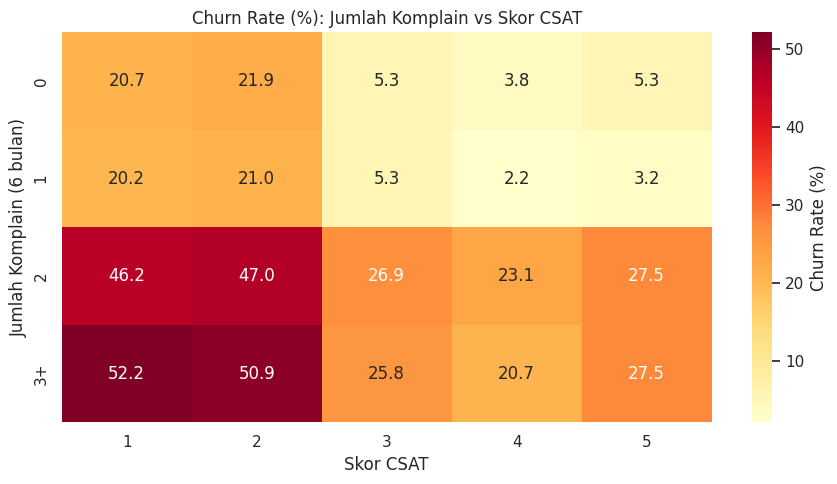

-> Kombinasi 'Komplain >= 2' DAN 'CSAT <= 2' menghasilkan churn rate
   tertinggi -- ini adalah SEGMEN PALING KRITIS untuk retensi.


In [11]:
# Bin komplain jadi kategori agar heatmap lebih rapi
df['komplain_cat'] = pd.cut(df['jumlah_komplain_6bln'], bins=[-1, 0, 1, 2, 100],
                              labels=['0', '1', '2', '3+'])

pivot = df.pivot_table(values='churn', index='komplain_cat',
                         columns='skor_kepuasan_csat', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Jumlah Komplain vs Skor CSAT')
ax.set_xlabel('Skor CSAT')
ax.set_ylabel('Jumlah Komplain (6 bulan)')
plt.tight_layout()
plt.show()

df = df.drop(columns=['komplain_cat'])

print("-> Kombinasi 'Komplain >= 2' DAN 'CSAT <= 2' menghasilkan churn rate")
print("   tertinggi -- ini adalah SEGMEN PALING KRITIS untuk retensi.")


* Dataset bersifat imbalanced dengan sekitar 15% pelanggan churn.
Implikasi: gunakan scale_pos_weight dan evaluasi model dengan ROC-AUC serta Recall, bukan hanya Accuracy.

* Pelanggan dengan tenure rendah, terutama di bawah 6 bulan, cenderung memiliki churn yang lebih tinggi.
Implikasi: buat fitur tenure_group melalui binning.

* Pelanggan dengan komplain >= 2 dan CSAT <= 2 memiliki churn rate tertinggi.
Implikasi: buat high_complain_flag dan low_csat_flag.

* Pengguna paket prabayar cenderung lebih tinggi churn-nya.
Implikasi: pertahankan sebagai fitur kategorikal penting.

* Pelanggan dengan streaming bundle dan e-wallet cenderung lebih rendah churn-nya.
Implikasi: jadikan sebagai fitur “stickiness” dan pertahankan.

* Tidak ditemukan multikolinearitas yang parah.
Implikasi: aman menggunakan model tree-based tanpa PCA.

* Interaksi antara komplain dan CSAT sangat informatif.
Implikasi: buat fitur gabungan seperti engagement score.